##Comment Toxicity Detection using NLP, Machine Learning, and Transformers

##Headings

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Text Preprocessing
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Model Comparison
9. Save Best Model

##1. Import Libraries

In [1]:
#Imports

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text PreProcessing
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#Custom Transformer

from sklearn.base import BaseEstimator, TransformerMixin

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import classification_report,confusion_matrix

# Machine Learning Models
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

#Transformer Imports
import torch

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset


In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

##2. Load Dataset

In [3]:
df_train = pd.read_csv('/content/train (3).csv')

In [4]:
df_train.shape

#(159571, 8)

(159571, 8)

In [5]:
df_train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [6]:
df_train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [8]:
df_train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

#Checking for Null Values

In [9]:
df_train.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


##Checking for Duplicates

In [10]:
df_train.duplicated().sum()

np.int64(0)

##2.Exploratory Data Analysis

In [11]:
#Creating a Binary column 'Label' for EDA Purpose:

df_train['label'] = df_train[
    ['toxic', 'severe_toxic', 'obscene',
     'threat', 'insult', 'identity_hate']
].max(axis=1)

df_train['label_name'] = df_train['label'].map({
    0: 'Non-toxic',
    1: 'Toxic'
})


In [12]:
df_train[['label','label_name']]

,label,label_name
0,0,Non-toxic
1,0,Non-toxic
2,0,Non-toxic
3,0,Non-toxic
4,0,Non-toxic
...,...,...
159566,0,Non-toxic
159567,0,Non-toxic
159568,0,Non-toxic
159569,0,Non-toxic


In [13]:
#Class Distribution

df_train['label_name'].value_counts()

,count
label_name,
Non-toxic,143346
Toxic,16225


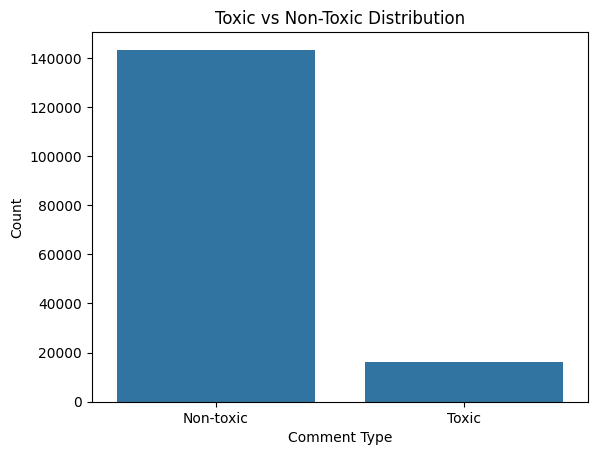

In [14]:
#Visualization Of Class Distribution

sns.countplot(x=df_train['label_name'])

plt.title("Toxic vs Non-Toxic Distribution")
plt.xlabel("Comment Type")
plt.ylabel("Count")

plt.show()

Observation from class distributions:

*   The dataset is highly imbalanced, with non-toxic comments
significantly outnumbering toxic comments.
*   Approximately 89.8% of comments are non-toxic, while only 10.2% are toxic.

In [15]:
#Class Imbalance Percentage

df_train['label_name'].value_counts(normalize=True) * 100

,proportion
label_name,
Non-toxic,89.832112
Toxic,10.167888


Observation from class imbalance percentage:

*   The dataset contains a severe class imbalance. The majority class is non-toxic comments, indicating that special attention should be given to evaluation metrics such as F1-score and recall during model evaluation.



In [16]:
#Comment Length

df_train['comment_length'] = df_train['comment_text'].apply(len)

In [17]:
#Comment Lenghth Distribution

df_train['comment_length']

,comment_length
0,264
1,112
2,233
3,622
4,67
...,...
159566,295
159567,99
159568,81
159569,116


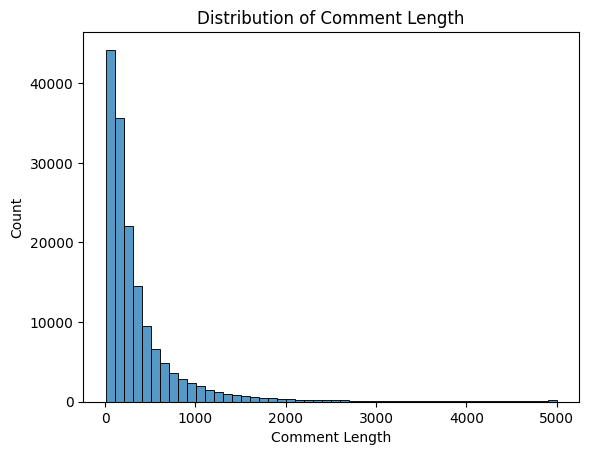

In [18]:
sns.histplot(df_train['comment_length'], bins=50)

plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")

plt.show()

Observation from Comment Lenghth Distribution:



---



*   Most comments in the dataset are relatively short in length, with only a small number of extremely long comments present.
*   The distribution is right-skewed, indicating the presence of outliers with very large comment lengths.

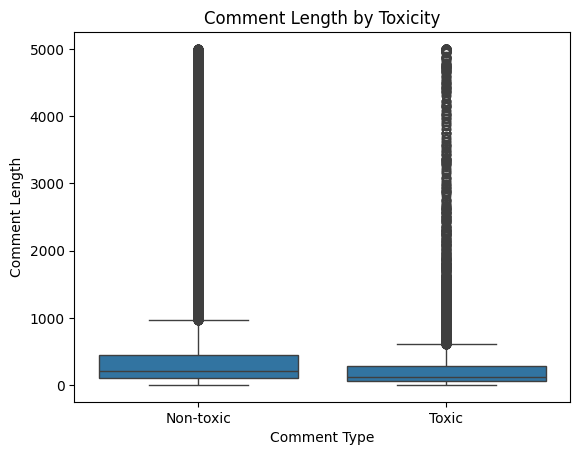

In [19]:
sns.boxplot(
    x='label_name',
    y='comment_length',
    data=df_train
)

plt.title("Comment Length by Toxicity")
plt.xlabel("Comment Type")
plt.ylabel("Comment Length")

plt.show()

Observation from Comment Lenghth by Toxicity:

---

*   Toxic comments tend to have slightly shorter median lengths compared to non-toxic comments.
*    However, both categories contain several long outlier comment

In [20]:
#Most Common Words

from collections import Counter

all_words = " ".join(df_train['comment_text']).split()

common_words = Counter(all_words).most_common(20)

common_words

[('the', 445987),
 ('to', 288817),
 ('of', 219334),
 ('and', 207381),
 ('a', 201817),
 ('I', 183930),
 ('is', 164639),
 ('you', 157272),
 ('that', 140545),
 ('in', 130262),
 ('for', 96010),
 ('it', 92651),
 ('on', 84453),
 ('not', 83944),
 ('"', 81755),
 ('be', 80928),
 ('this', 71429),
 ('have', 69414),
 ('as', 68345),
 ('are', 66277)]

Observation from Most Common Words:

*   The most common words mainly consist of stopwords such as “the”, “to”, and “of”.
*   This indicates that text preprocessing steps like stopword removal will be important before model training.



In [21]:
#Toxic Words

toxic_comments = df_train[df_train['label'] == 1]

toxic_words = " ".join(toxic_comments['comment_text']).split()

Counter(toxic_words).most_common(20)

[('you', 20346),
 ('the', 19018),
 ('a', 18988),
 ('I', 17760),
 ('to', 15945),
 ('and', 14856),
 ('is', 11308),
 ('of', 11198),
 ('your', 7732),
 ('YOU', 7433),
 ('that', 7419),
 ('are', 6357),
 ('in', 6061),
 ('You', 5170),
 ('it', 4942),
 ('on', 4838),
 ('for', 4709),
 ('my', 4562),
 ('have', 4497),
 ('not', 4380)]

Observation from Toxic Words:



*   The toxic comments still contain many common English stopwords because preprocessing has not yet been applied.
*   More meaningful toxic keywords are expected to appear after text cleaning and stopword removal.

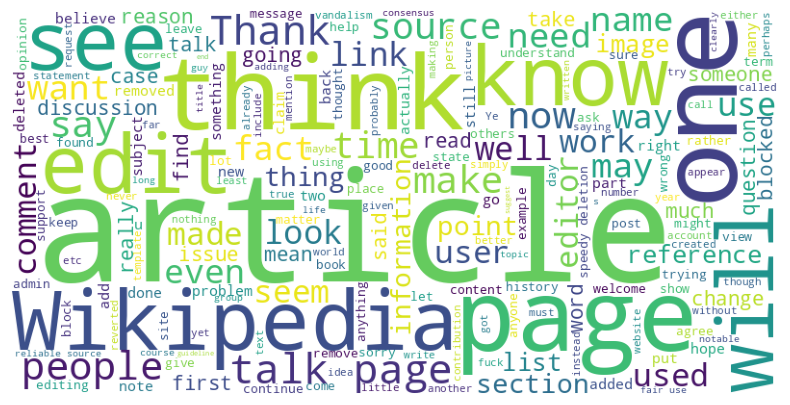

In [22]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(df_train['comment_text']))

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

Observation from Word Cloud :

*   The WordCloud visualization highlights the most frequently occurring words in the dataset.
*   Terms such as “article”, “Wikipedia”, and “edit” appear prominently because the dataset is derived from Wikipedia discussion comments.

##4. Custom Transformer for text Preprocessing

Text Preprocessing Techniques:

1. Lowercasing
2. Remove URLs
3. Remove special characters
4. Remove numbers
5. Remove extra spaces
6. Tokenization
7. Stopword removal
8. Lemmatization

In [23]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
#Custom Transformer

class TextPreprocessor(BaseEstimator, TransformerMixin):
   def __init__(self):
     self.stop_word = set(stopwords.words('english'))
     self.lemmatizer = WordNetLemmatizer()
     self.word_tokenize = word_tokenize

   def text_cleaning(self,text):
      text=str(text).lower()
      #remove links
      text= re.sub(r'https?://\S+|www\.\S+',' ',text)
      #remove hashtags
      text=re.sub(r'#\w+',' ',text)
      #remove mentions
      text = re.sub(r'@\w+',' ',text)
      #mail-id
      text=re.sub(r'\S+@\S+',' ',text)
      text=re.sub(r'[^a-z0-9\s]',' ',text)
      #remove whitespaces
      text = re.sub(r'\s+', ' ', text).strip()
      return text
   def tokenize_lemmatize(self,text):
      tokens=self.word_tokenize(text)
      return ' '.join([self.lemmatizer.lemmatize(word) for word in tokens if word not in self.stop_word])

   def fit(self,X,Y=None):
      return self

   def transform(self, X, y=None):
      return [self.tokenize_lemmatize(self.text_cleaning(text)) for text in X]


In [25]:
#Testing Text Preprocessor

sample_text = [
    "YOU are an IDIOT!!! Visit https://abc.com now!!!"
]

preprocessor = TextPreprocessor()

preprocessor.transform(sample_text)

['idiot visit']

##Splitting X and Y

In [26]:
X = df_train['comment_text']
y = df_train[
    [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
]

#Splitting X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##1. Multinomial NB Model

In [27]:
NB_pipeline = Pipeline([

    ('PreProcess', TextPreprocessor()),

    ('TF-IDF', TfidfVectorizer()),

    ('Multinomial_Model',
     OneVsRestClassifier(MultinomialNB()))
])

In [28]:
#Model Training

NB_pipeline.fit(X_train, y_train)

Pipeline(steps=[('PreProcess', TextPreprocessor()),
                ('TF-IDF', TfidfVectorizer()),
                ('Multinomial_Model',
                 OneVsRestClassifier(estimator=MultinomialNB()))])

In [29]:
#Prediction

y_pred_nb = NB_pipeline.predict(X_test)

In [30]:
#Evaluation for MultinomialNB Classifier

target_names = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=target_names
    )
)

               precision    recall  f1-score   support

        toxic       0.99      0.19      0.32      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.98      0.12      0.21      1715
       threat       0.00      0.00      0.00        74
       insult       0.96      0.05      0.10      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.99      0.12      0.22      7074
    macro avg       0.49      0.06      0.11      7074
 weighted avg       0.88      0.12      0.21      7074
  samples avg       0.02      0.01      0.01      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Observation from MultinomialNB Model



*   The Multinomial Naive Bayes model achieved poor performance on minority toxicity categories such as severe_toxic, threat, and identity_hate.

*   Although the model showed relatively high precision for some classes, recall values were extremely low, indicating that the classifier failed to identify many toxic comments.

*   This behavior is primarily caused by the severe class imbalance present in the dataset.



##2. Logistic Regression Model

In [31]:
LR_pipeline = Pipeline([

    ('PreProcess', TextPreprocessor()),

    ('TF-IDF', TfidfVectorizer()),

    ('LogisticRegression_Model',
     OneVsRestClassifier(LogisticRegression(max_iter=1000)))
])

In [32]:
#Model Training

LR_pipeline.fit(X_train, y_train)

Pipeline(steps=[('PreProcess', TextPreprocessor()),
                ('TF-IDF', TfidfVectorizer()),
                ('LogisticRegression_Model',
                 OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000)))])

In [33]:
#Prediction

y_pred_lr = LR_pipeline.predict(X_test)

In [34]:
#Evaluation for MultinomialNB Classifier

target_names = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=target_names
    )
)

               precision    recall  f1-score   support

        toxic       0.91      0.61      0.73      3056
 severe_toxic       0.61      0.28      0.38       321
      obscene       0.91      0.63      0.74      1715
       threat       0.43      0.08      0.14        74
       insult       0.82      0.52      0.64      1614
identity_hate       0.74      0.16      0.26       294

    micro avg       0.88      0.55      0.68      7074
    macro avg       0.74      0.38      0.48      7074
 weighted avg       0.87      0.55      0.67      7074
  samples avg       0.06      0.05      0.05      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Observation from LogisticRegression Model :



*   The Logistic Regression model significantly outperformed the Multinomial Naive Bayes classifier across most toxicity categories.
*   The model achieved strong performance on frequently occurring labels such as toxic, obscene, and insult, while performance remained relatively weak for rare labels like threat and identity_hate due to severe class imbalance.



Insights :

Linear models such as Logistic Regression often perform strongly in NLP tasks because TF-IDF generates high-dimensional sparse feature vectors that are well suited for linear classifiers.




Why Logistic Regression is best ?

Logistic Regression achieved the best balance between precision, recall, and F1-score across most toxicity categories.

##3. Linear Support Vector Classifier

In [35]:
SVC_pipeline = Pipeline([

    ('PreProcess', TextPreprocessor()),

    ('TF-IDF', TfidfVectorizer()),

    ('LinearSVC_Model',
     OneVsRestClassifier(LinearSVC()))

])

In [36]:
#Model Training

SVC_pipeline.fit(X_train, y_train)

Pipeline(steps=[('PreProcess', TextPreprocessor()),
                ('TF-IDF', TfidfVectorizer()),
                ('LinearSVC_Model',
                 OneVsRestClassifier(estimator=LinearSVC()))])

In [37]:
#Prediction

y_pred_svc = SVC_pipeline.predict(X_test)

In [38]:
target_names = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

print(
    classification_report(
        y_test,
        y_pred_svc,
        target_names=target_names
    )
)

               precision    recall  f1-score   support

        toxic       0.87      0.70      0.77      3056
 severe_toxic       0.56      0.32      0.41       321
      obscene       0.89      0.71      0.79      1715
       threat       0.52      0.22      0.30        74
       insult       0.79      0.58      0.67      1614
identity_hate       0.69      0.27      0.38       294

    micro avg       0.84      0.63      0.72      7074
    macro avg       0.72      0.47      0.56      7074
 weighted avg       0.83      0.63      0.72      7074
  samples avg       0.06      0.06      0.06      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Observation from Linear SVC:



*   Among the classical machine learning models evaluated, LinearSVC achieved the best overall performance for multi-label toxicity classification using TF-IDF features.

*   The LinearSVC model outperformed both Multinomial Naive Bayes and Logistic Regression across most toxicity categories.
*    The model achieved the highest micro-average and weighted-average F1-scores, demonstrating strong capability in handling high-dimensional sparse textual data generated through TF-IDF vectorization.
*   Although the model performed well on frequently occurring labels such as toxic and obscene, performance remained comparatively lower for rare categories like threat and identity_hate due to severe class imbalance in the dataset.



##4. BERT Transformer Model :


In [39]:
!pip install transformers datasets accelerate -q

In [40]:
#Creating New DataFrames

train_df = pd.DataFrame({
    'text': X_train,
})

train_df = pd.concat(
    [train_df, y_train.reset_index(drop=True)],
    axis=1
)

test_df = pd.DataFrame({
    'text': X_test,
})

test_df = pd.concat(
    [test_df, y_test.reset_index(drop=True)],
    axis=1
)

In [41]:
#Convert to HuggingFace Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [42]:
#Loading Tokenizer

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [45]:
#Tokenization Function

def tokenize_function(example):

  text = str(example["text"])

  return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [46]:
train_dataset = train_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)

Map:   0%|          | 0/153105 [00:00<?, ? examples/s]

Map:   0%|          | 0/57624 [00:00<?, ? examples/s]

In [49]:
label_columns = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

def format_labels(example):

    example['labels'] = [
        float(example[label]) if example[label] is not None else 0.0
        for label in label_columns
    ]

    return example

In [50]:
train_dataset = train_dataset.map(format_labels)
test_dataset = test_dataset.map(format_labels)

Map:   0%|          | 0/153105 [00:00<?, ? examples/s]

Map:   0%|          | 0/57624 [00:00<?, ? examples/s]

In [51]:
#Removing Unnecessary COlumns
train_dataset = train_dataset.remove_columns(
    ['text'] + label_columns
)

test_dataset = test_dataset.remove_columns(
    ['text'] + label_columns
)

In [52]:
train_dataset.set_format('torch')
test_dataset.set_format('torch')

In [53]:
#Loading BERT Model

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=6,
    problem_type='multi_label_classification'
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [55]:
training_args = TrainingArguments(

    output_dir='./results',

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=1,

    eval_strategy='epoch',

    save_strategy='epoch',

    logging_steps=100
)

In [56]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss


In [ ]:
#For streamlit app predictions : include multilabel prob(Category, prediction) and  Overall Toxicity Probability: 87%

“Why still use BERT if LinearSVC already performs well?”

Answer:

Classical ML models depend on handcrafted features like TF-IDF.
BERT learns semantic contextual understanding automatically.
BERT captures deeper language relationships and sarcasm/toxicity patterns better.

In Toxicity Detection

Usually:

Recall is VERY important.

Because:

Missing toxic comments is dangerous.

Example:

Actual toxic comment
→ predicted as safe

This is worse than:

falsely flagging some safe comments.